In [ ]:
import keras
import tensorflow.keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.layers import Conv2D, MaxPooling2D
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD

In [ ]:
# import dataset and split into train and test data
(x_train,y_train),(x_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# check shape of different datasets
print('Train Dataset (x):',x_train.shape)
print('Train Dataset (y):',y_train.shape)
print('Test Dataset (x):',x_test.shape)
print('Test Dataset (y):',y_test.shape)

Train Dataset (x): (60000, 28, 28)
Train Dataset (y): (60000,)
Test Dataset (x): (10000, 28, 28)
Test Dataset (y): (10000,)


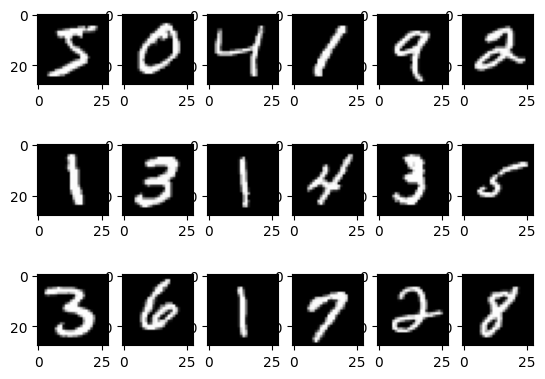

In [ ]:
# check few images of this dataset
# plot first few images
for i in range (18):
  # define subplot
  plt.subplot(3,6,1+i)
  # plot raw pixel data
  plt.imshow(x_train[i],cmap=plt.get_cmap('gray'))
# show
plt.show()

In [ ]:
# reshape the training and testing data
x_train = x_train.reshape(x_train.shape[0],28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)
input_shape = (28,28,1)

In [ ]:
# convert class vectors to binary class matrix
from tensorflow.keras.utils import to_categorical
num_classes = 0
y_train = to_categorical(y_train,num_classes)
y_test = to_categorical(y_test,num_classes)

In [ ]:
# convert from integers to float
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [ ]:
# normalize to range 0 to 1
x_train /= 255
x_test /= 255

In [ ]:
# check the normalised images
print('x_train shape:',x_train.shape)
print(x_train.shape[0],'train samples')
print(x_test.shape[0],'test samples')

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
from tensorflow.keras.optimizers import Adamax
# set values for major parameters for model training
batch_size = 128
num_classes = 10
epochs = 20

# builfing model
# adding layers one by one
# since this is a classification problem
# activation function for hidden layer - relu
# activation function for output layer - softmax
# input shape (since grayscale) - (28,28,1)
# output shape - 10

In [ ]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(num_classes,activation='softmax'))

# model compilation
# this is a multi class classification problem
# thus loss function - categorical cross entro;py and metrics as accuracy
# optimizer beign used is SGD (Stochastic Gradient Descent)
# lr stands for learning rate

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
opt_adamax = Adamax(learning_rate=0.002)
model.compile(loss='categorical_crossentropy',optimizer=opt_adamax,metrics=['accuracy'])

In [ ]:
# model training
# fit dataset into model
# save the nodel as well after training

hist = model.fit(x_train,y_train,batch_size = batch_size, epochs=epochs,verbose=1,validation_data=(x_test,y_test))
print('The model has successfully trained')
model.save('mnist.h5')
print('Saving the model as mnist.h5')

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 118ms/step - accuracy: 0.9399 - loss: 0.2060 - val_accuracy: 0.9762 - val_loss: 0.0828
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.9785 - loss: 0.0740 - val_accuracy: 0.9800 - val_loss: 0.0680
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - accuracy: 0.9847 - loss: 0.0520 - val_accuracy: 0.9836 - val_loss: 0.0484
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.9886 - loss: 0.0390 - val_accuracy: 0.9832 - val_loss: 0.0532
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 76s 98ms/step - accuracy: 0.9916 - loss: 0.0293 - val_accuracy: 0.9854 - val_loss: 0.0418
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.9936 - loss: 0.0230 - val_accuracy: 0.9851 - val_loss: 0.0430
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - accuracy: 0.9952 - loss: 0.0179 - val_accuracy: 0.9848 - val_loss: 0.0416
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 118ms/step - accuracy: 0.9963 - loss: 0.

The model has successfully trained
Saving the model as mnist.h5


In [ ]:
# model evaluaion
score = model.evaluate(x_test,y_test,verbose=0)
print('Test loss:',score[0])
print('Test accuracy:',score[1])

Test loss: 0.04897421970963478
Test accuracy: 0.9869999885559082


In [ ]:
# digit recognition using this model
# make a prisiction for a new image
from numpy import argmax
from keras.preprocessing.image import load_img
from keras.models import load_model

In [ ]:
from google.colab import files
files = files.upload()

Saving 1531505139109.png to 1531505139109 (1).png


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array

def load_image(filename):
    img = load_img(filename, color_mode="grayscale", target_size=(28,28))
    img = img_to_array(img)
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    return img


In [ ]:
# load an image and predict teh class
def run_example():
  # load the image
  img = load_image('1531505139109 (1).png')
  # load model
  model = load_model('mnist.h5')
  # predict the class
  predict_value = model.predict(img)
  digit = argmax(predict_max)
  print(digit)

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
# entry point, run the example

def run_example():
    filenames = ['1531505139109.png']

    model = load_model('mnist.h5')

    for filename in filenames:
        img = load_image(filename)

        predict_value = model.predict(img)

        digit = np.argmax(predict_value)

        print(f'File: {filename} | Predicted Digit: {digit}')

run_example()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
File: 1531505139109.png | Predicted Digit: 3
